# Human Detection using HOG + SVM + Hard Negative Mining

**Project:** Object Detection with HOG/SVM  
**Dataset:** INRIA Person / Pascal VOC XML  
**Aplikasi akhir:** Streamlit Human Detection App

Notebook ini melatih detektor manusia berbasis:
1. Ekstraksi fitur **Histogram of Oriented Gradients (HOG)**
2. Klasifikasi **Linear SVM**
3. Deteksi multi-skala menggunakan **Image Pyramid + Sliding Window**
4. Pengurangan box ganda menggunakan **Non-Maximum Suppression (NMS)**
5. Peningkatan model menggunakan **Hard Negative Mining**

Hard Negative Mining membuat model lebih tahan terhadap background yang mirip manusia, seperti tiang, pohon, tembok, atau objek vertikal lain.

In [1]:
import os
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from skimage.feature import hog
from skimage.transform import pyramid_gaussian
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1. Path Dataset

Letak dataset

In [2]:
DATASET_DIR = Path("dataset")

TRAIN_IMG_DIR = DATASET_DIR / "Train" / "JPEGImages"
TRAIN_ANN_DIR = DATASET_DIR / "Train" / "Annotations"
TEST_IMG_DIR  = DATASET_DIR / "Test" / "JPEGImages"
TEST_ANN_DIR  = DATASET_DIR / "Test" / "Annotations"

print("Train images     :", TRAIN_IMG_DIR)
print("Train annotations:", TRAIN_ANN_DIR)
print("Test images      :", TEST_IMG_DIR)
print("Test annotations :", TEST_ANN_DIR)

Train images     : dataset\Train\JPEGImages
Train annotations: dataset\Train\Annotations
Test images      : dataset\Test\JPEGImages
Test annotations : dataset\Test\Annotations


In [3]:
train_images = sorted(list(TRAIN_IMG_DIR.glob("*.png")) + list(TRAIN_IMG_DIR.glob("*.jpg")) + list(TRAIN_IMG_DIR.glob("*.jpeg")))
train_annotations = sorted(list(TRAIN_ANN_DIR.glob("*.xml")))

test_images = sorted(list(TEST_IMG_DIR.glob("*.png")) + list(TEST_IMG_DIR.glob("*.jpg")) + list(TEST_IMG_DIR.glob("*.jpeg")))
test_annotations = sorted(list(TEST_ANN_DIR.glob("*.xml")))

print("Jumlah train image     :", len(train_images))
print("Jumlah train annotation:", len(train_annotations))
print("Jumlah test image      :", len(test_images))
print("Jumlah test annotation :", len(test_annotations))

Jumlah train image     : 614
Jumlah train annotation: 614
Jumlah test image      : 288
Jumlah test annotation : 288


## 2. Fungsi Utility Dataset Pascal VOC

In [4]:
def parse_voc_xml(xml_path):
    """Membaca annotation Pascal VOC XML dan mengambil semua bounding box person."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    boxes = []

    for obj in root.findall("object"):
        name = obj.findtext("name")
        if name is None or name.lower() != "person":
            continue

        bndbox = obj.find("bndbox")
        xmin = int(float(bndbox.findtext("xmin")))
        ymin = int(float(bndbox.findtext("ymin")))
        xmax = int(float(bndbox.findtext("xmax")))
        ymax = int(float(bndbox.findtext("ymax")))

        boxes.append((xmin, ymin, xmax, ymax))

    return filename, boxes


def find_image_path(image_dir, filename):
    """Mencari path gambar berdasarkan filename dari XML, dengan fallback ekstensi."""
    image_path = image_dir / filename
    if image_path.exists():
        return image_path

    stem = Path(filename).stem
    for ext in [".png", ".jpg", ".jpeg", ".bmp"]:
        candidate = image_dir / f"{stem}{ext}"
        if candidate.exists():
            return candidate

    return None


def load_rgb_image(image_path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        return None
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def draw_boxes(image, boxes, color=(0, 255, 0), thickness=2, labels=None):
    img = image.copy()
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box[:4])
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        if labels is not None:
            cv2.putText(img, str(labels[i]), (x1, max(20, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img

## 3. Visualisasi Sample Bounding Box

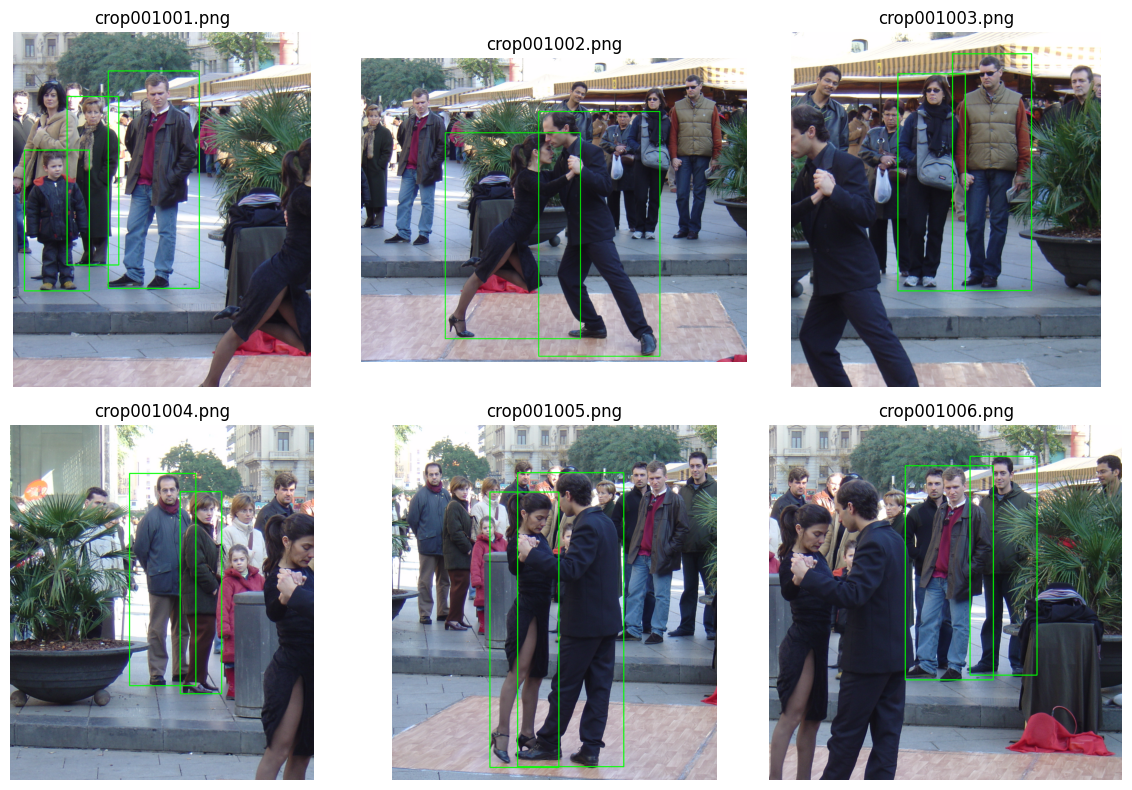

In [5]:
plt.figure(figsize=(12, 8))
plot_idx = 1

for xml_path in train_annotations[:6]:
    filename, boxes = parse_voc_xml(xml_path)
    img_path = find_image_path(TRAIN_IMG_DIR, filename)

    if img_path is None:
        continue

    image = load_rgb_image(img_path)
    if image is None:
        continue

    image_box = draw_boxes(image, boxes)

    plt.subplot(2, 3, plot_idx)
    plt.imshow(image_box)
    plt.title(filename)
    plt.axis("off")
    plot_idx += 1

    if plot_idx > 6:
        break

plt.tight_layout()
plt.show()

## 4. Konfigurasi HOG

Ukuran window klasik pedestrian detection dari HOG adalah **64 x 128**.

Catatan:
- `WINDOW_SIZE = (width, height)`
- Semua positive dan negative crop akan di-resize ke ukuran ini.

In [6]:
WINDOW_SIZE = (64, 128)  # width, height

HOG_PARAMS = {
    "orientations": 9,
    "pixels_per_cell": (8, 8),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys",
    "transform_sqrt": True,
    "feature_vector": True
}

def extract_hog_features(image):
    """Resize image ke WINDOW_SIZE lalu ekstrak fitur HOG grayscale."""
    resized = cv2.resize(image, WINDOW_SIZE)

    if len(resized.shape) == 3:
        gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    else:
        gray = resized

    return hog(gray, **HOG_PARAMS)

## 5. Fungsi IoU, Crop Positive, dan Random Negative

In [7]:
def compute_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter_area

    return 0 if union == 0 else inter_area / union


def clip_box(box, width, height):
    x1, y1, x2, y2 = box
    x1 = max(0, min(width - 1, int(x1)))
    y1 = max(0, min(height - 1, int(y1)))
    x2 = max(0, min(width, int(x2)))
    y2 = max(0, min(height, int(y2)))
    return (x1, y1, x2, y2)


def expand_box(box, width, height, scale=1.08):
    """Memberi sedikit padding pada bbox person agar fitur badan tidak terlalu terpotong."""
    x1, y1, x2, y2 = box
    bw = x2 - x1
    bh = y2 - y1
    cx = x1 + bw / 2
    cy = y1 + bh / 2

    new_w = bw * scale
    new_h = bh * scale

    nx1 = cx - new_w / 2
    ny1 = cy - new_h / 2
    nx2 = cx + new_w / 2
    ny2 = cy + new_h / 2

    return clip_box((nx1, ny1, nx2, ny2), width, height)


def random_negative_crop(image, positive_boxes, crop_size=(64, 128),
                         max_attempts=150, iou_threshold=0.05,
                         scale_jitter=(1.0, 2.0)):
    """
    Mengambil crop background acak yang tidak overlap dengan person.

    Perbedaan dari versi awal:
    - ukuran crop boleh bervariasi lalu di-resize ke 64x128
    - ini membuat negative sample lebih beragam
    """
    h, w = image.shape[:2]
    base_w, base_h = crop_size

    for _ in range(max_attempts):
        scale = random.uniform(*scale_jitter)
        crop_w = int(base_w * scale)
        crop_h = int(base_h * scale)

        if w < crop_w or h < crop_h:
            continue

        x1 = random.randint(0, w - crop_w)
        y1 = random.randint(0, h - crop_h)
        x2 = x1 + crop_w
        y2 = y1 + crop_h

        candidate_box = (x1, y1, x2, y2)
        max_iou = max([compute_iou(candidate_box, box) for box in positive_boxes], default=0)

        if max_iou < iou_threshold:
            return image[y1:y2, x1:x2], candidate_box

    return None, None

## 6. Build Dataset Awal

Dataset awal dibuat dari:
- **Positive sample:** crop berdasarkan bbox `person`
- **Negative sample:** crop acak dari background yang tidak overlap dengan bbox person

Parameter penting:
- `negative_per_image`: naikkan kalau false positive masih banyak
- `limit`: isi angka kecil untuk percobaan cepat, gunakan `None` untuk full training

In [8]:
def build_samples(image_dir, ann_dir, negative_per_image=3, limit=None, positive_padding=1.08):
    X, y = [], []
    meta = []

    xml_files = sorted(list(ann_dir.glob("*.xml")))
    if limit is not None:
        xml_files = xml_files[:limit]

    positive_count, negative_count, skipped = 0, 0, 0

    for xml_path in tqdm(xml_files, desc="Building initial samples"):
        filename, boxes = parse_voc_xml(xml_path)
        img_path = find_image_path(image_dir, filename)

        if img_path is None:
            skipped += 1
            continue

        image = load_rgb_image(img_path)
        if image is None:
            skipped += 1
            continue

        h, w = image.shape[:2]
        boxes = [clip_box(box, w, h) for box in boxes]

        # Positive samples
        for box in boxes:
            x1, y1, x2, y2 = expand_box(box, w, h, scale=positive_padding)

            if x2 <= x1 or y2 <= y1:
                continue

            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            X.append(extract_hog_features(crop))
            y.append(1)
            meta.append({"type": "positive", "image": str(img_path), "box": (x1, y1, x2, y2)})
            positive_count += 1

        # Random negative samples
        for _ in range(negative_per_image):
            neg_crop, neg_box = random_negative_crop(
                image=image,
                positive_boxes=boxes,
                crop_size=WINDOW_SIZE,
                iou_threshold=0.05,
                scale_jitter=(1.0, 2.2)
            )

            if neg_crop is None:
                continue

            X.append(extract_hog_features(neg_crop))
            y.append(0)
            meta.append({"type": "random_negative", "image": str(img_path), "box": neg_box})
            negative_count += 1

    print(f"Positive samples      : {positive_count}")
    print(f"Random negative samples: {negative_count}")
    if skipped > 0:
        print(f"Skipped files         : {skipped}")

    return np.array(X), np.array(y), meta

In [9]:
X, y, sample_meta = build_samples(
    image_dir=TRAIN_IMG_DIR,
    ann_dir=TRAIN_ANN_DIR,
    negative_per_image=3,
    limit=None  
)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Distribusi label [Non-Human, Human]:", np.bincount(y))

Building initial samples: 100%|██████████| 614/614 [00:23<00:00, 26.52it/s]

Positive samples      : 1240
Random negative samples: 1842
Shape X: (3082, 3780)
Shape y: (3082,)
Distribusi label [Non-Human, Human]: [1842 1240]


## 7. Split Data Training dan Validation

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)

X_train: (2465, 3780)
X_val  : (617, 3780)


## 8. Training Model Awal

Model awal dipakai untuk mencari **false positive** pada tahap Hard Negative Mining.

In [11]:
def create_svm_model(C=0.1):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(
            C=C,
            class_weight="balanced",
            max_iter=20000,
            random_state=RANDOM_STATE
        ))
    ])

# C=0.1 untuk initial model: cukup ekspresif untuk menemukan hard negative
# C akan di-tune lagi saat retrain final
INITIAL_C = 0.1

initial_model = create_svm_model(C=INITIAL_C)
initial_model.fit(X_train, y_train)

print("Training model awal selesai.")


Training model awal selesai.


Initial Validation Accuracy: 0.9643435980551054
              precision    recall  f1-score   support

   Non-Human       0.98      0.96      0.97       369
       Human       0.94      0.97      0.96       248

    accuracy                           0.96       617
   macro avg       0.96      0.97      0.96       617
weighted avg       0.96      0.96      0.96       617



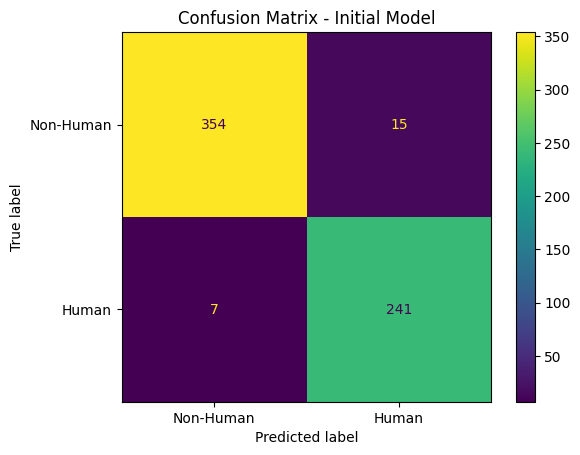

In [12]:
initial_pred = initial_model.predict(X_val)

print("Initial Validation Accuracy:", accuracy_score(y_val, initial_pred))
print(classification_report(y_val, initial_pred, target_names=["Non-Human", "Human"]))

cm_initial = confusion_matrix(y_val, initial_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_initial, display_labels=["Non-Human", "Human"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Initial Model")
plt.show()

## 9. Sliding Window + Gaussian Pyramid

Fungsi ini dipakai untuk:
1. Demo deteksi
2. Hard Negative Mining
3. Streamlit nanti

Format output detection:
```text
(x1, y1, score, width, height)
```
koordinat sudah dikembalikan ke ukuran gambar asli.

In [13]:
def sliding_window(image, step_size=10, window_size=(64, 128)):
    win_w, win_h = window_size
    h, w = image.shape[:2]

    for y in range(0, h - win_h + 1, step_size):
        for x in range(0, w - win_w + 1, step_size):
            yield (x, y, image[y:y + win_h, x:x + win_w])


def detect_humans_multiscale(image, model, step_size=10, threshold=0.8,
                             downscale=1.25, max_levels=None):
    detections = []
    has_decision_fn = hasattr(model, "decision_function")

    for level, resized in enumerate(
        pyramid_gaussian(image, downscale=downscale, channel_axis=-1)
    ):
        if max_levels is not None and level >= max_levels:
            break

        if resized.shape[0] < WINDOW_SIZE[1] or resized.shape[1] < WINDOW_SIZE[0]:
            break

        resized_uint8 = (resized * 255).astype(np.uint8) if resized.max() <= 1.0 else resized.astype(np.uint8)

        for (x, y, window) in sliding_window(
            resized_uint8,
            step_size=step_size,
            window_size=WINDOW_SIZE
        ):
            if window.shape[0] != WINDOW_SIZE[1] or window.shape[1] != WINDOW_SIZE[0]:
                continue

            features = extract_hog_features(window).reshape(1, -1)
            pred = model.predict(features)[0]

            if pred == 1:
                score = float(model.decision_function(features)[0]) if has_decision_fn else 1.0

                if score >= threshold:
                    scale_factor = downscale ** level
                    x1 = int(x * scale_factor)
                    y1 = int(y * scale_factor)
                    w  = int(WINDOW_SIZE[0] * scale_factor)
                    h  = int(WINDOW_SIZE[1] * scale_factor)

                    detections.append((x1, y1, score, w, h))

    return detections

## 10. Non-Maximum Suppression

In [14]:
def non_max_suppression(detections, iou_threshold=0.35):
    """NMS pada detections format (x1, y1, score, w, h)."""
    if len(detections) == 0:
        return []

    rects = np.array([[x, y, x + w, y + h] for (x, y, _, w, h) in detections], dtype=float)
    scores = np.array([score for (_, _, score, _, _) in detections], dtype=float)

    x1, y1, x2, y2 = rects[:, 0], rects[:, 1], rects[:, 2], rects[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []

    while order.size > 0:
        i = order[0]
        keep.append(i)

        if order.size == 1:
            break

        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        inter_w = np.maximum(0, xx2 - xx1)
        inter_h = np.maximum(0, yy2 - yy1)
        inter = inter_w * inter_h

        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        order = order[np.where(iou <= iou_threshold)[0] + 1]

    final = []
    for idx in keep:
        box = rects[idx].astype(int).tolist()
        score = float(scores[idx])
        final.append((box[0], box[1], box[2], box[3], score))

    return final

## 11. Hard Negative Mining

Cara kerja:
1. Jalankan model awal ke gambar training.
2. Deteksi yang diprediksi sebagai manusia dicek IoU-nya dengan ground truth.
3. Jika IoU kecil, artinya itu **false positive**.
4. Crop false positive tersebut.
5. Tambahkan sebagai negative sample baru.
6. Retrain SVM.

Parameter penting:
- `HNM_THRESHOLD`: threshold deteksi saat mining. Jangan terlalu tinggi agar false positive terkumpul.
- `HNM_IOU_THRESHOLD`: jika overlap dengan person kurang dari nilai ini, dianggap false positive.
- `MAX_HARD_NEG_PER_IMAGE`: batas negative sulit per gambar agar dataset tidak terlalu berat.

In [15]:
def mine_hard_negatives(image_dir, ann_dir, model,
                        limit_images=300,
                        step_size=16,
                        threshold=0.25,
                        downscale=1.35,
                        max_levels=None,
                        iou_threshold=0.10,
                        max_hard_neg_per_image=8):
    hard_X = []
    hard_meta = []

    xml_files = sorted(list(ann_dir.glob("*.xml")))
    if limit_images is not None:
        xml_files = xml_files[:limit_images]

    for xml_path in tqdm(xml_files, desc="Hard Negative Mining"):
        filename, gt_boxes = parse_voc_xml(xml_path)
        img_path = find_image_path(image_dir, filename)

        if img_path is None:
            continue

        image = load_rgb_image(img_path)
        if image is None:
            continue

        h, w = image.shape[:2]
        gt_boxes = [clip_box(box, w, h) for box in gt_boxes]

        detections = detect_humans_multiscale(
            image=image,
            model=model,
            step_size=step_size,
            threshold=threshold,
            downscale=downscale,
            max_levels=max_levels
        )

        # Ambil yang paling percaya diri dulu
        detections = sorted(detections, key=lambda d: d[2], reverse=True)

        per_image_count = 0

        for (x1, y1, score, bw, bh) in detections:
            x2 = x1 + bw
            y2 = y1 + bh
            det_box = clip_box((x1, y1, x2, y2), w, h)

            max_iou = max([compute_iou(det_box, gt) for gt in gt_boxes], default=0)

            # False positive: confidence tinggi tapi tidak overlap dengan ground truth person
            if max_iou < iou_threshold:
                cx1, cy1, cx2, cy2 = det_box

                if cx2 <= cx1 or cy2 <= cy1:
                    continue

                crop = image[cy1:cy2, cx1:cx2]
                if crop.size == 0:
                    continue

                hard_X.append(extract_hog_features(crop))
                hard_meta.append({
                    "image": str(img_path),
                    "box": det_box,
                    "score": score,
                    "max_iou": max_iou
                })

                per_image_count += 1

                if per_image_count >= max_hard_neg_per_image:
                    break

    hard_X = np.array(hard_X)
    hard_y = np.zeros(len(hard_X), dtype=int)

    print("Jumlah hard negative ditemukan:", len(hard_X))
    return hard_X, hard_y, hard_meta

In [16]:
# ── Hard Negative Mining Parameters ──────────────────────────────────────────
# limit_images=None → pakai semua gambar training (lebih baik tapi lebih lambat)
# Untuk eksperimen cepat ubah ke limit_images=200

HNM_LIMIT_IMAGES      = None
HNM_STEP_SIZE         = 16     # step lebih besar = HNM lebih cepat, cukup untuk mining
HNM_THRESHOLD         = 0.3    # 0.3: ambil false positive yang cukup confident
                                # (0.25 terlalu rendah → terlalu banyak noise masuk)
HNM_DOWNSCALE         = 1.25   # 1.25 lebih banyak level pyramid → lebih banyak hard neg
HNM_IOU_THRESHOLD     = 0.10   # deteksi yang overlap < 10% dengan GT dianggap false pos
MAX_HARD_NEG_PER_IMAGE = 8     # batasi agar tidak dominated satu gambar

X_hard, y_hard, hard_meta = mine_hard_negatives(
    image_dir=TRAIN_IMG_DIR,
    ann_dir=TRAIN_ANN_DIR,
    model=initial_model,
    limit_images=HNM_LIMIT_IMAGES,
    step_size=HNM_STEP_SIZE,
    threshold=HNM_THRESHOLD,
    downscale=HNM_DOWNSCALE,
    iou_threshold=HNM_IOU_THRESHOLD,
    max_hard_neg_per_image=MAX_HARD_NEG_PER_IMAGE
)

print("X_hard shape:", X_hard.shape)


Hard Negative Mining: 100%|██████████| 614/614 [2:04:09<00:00, 12.13s/it]  


Jumlah hard negative ditemukan: 4657
X_hard shape: (4657, 3780)


## 12. Visualisasi Hard Negative yang Berhasil Ditambang

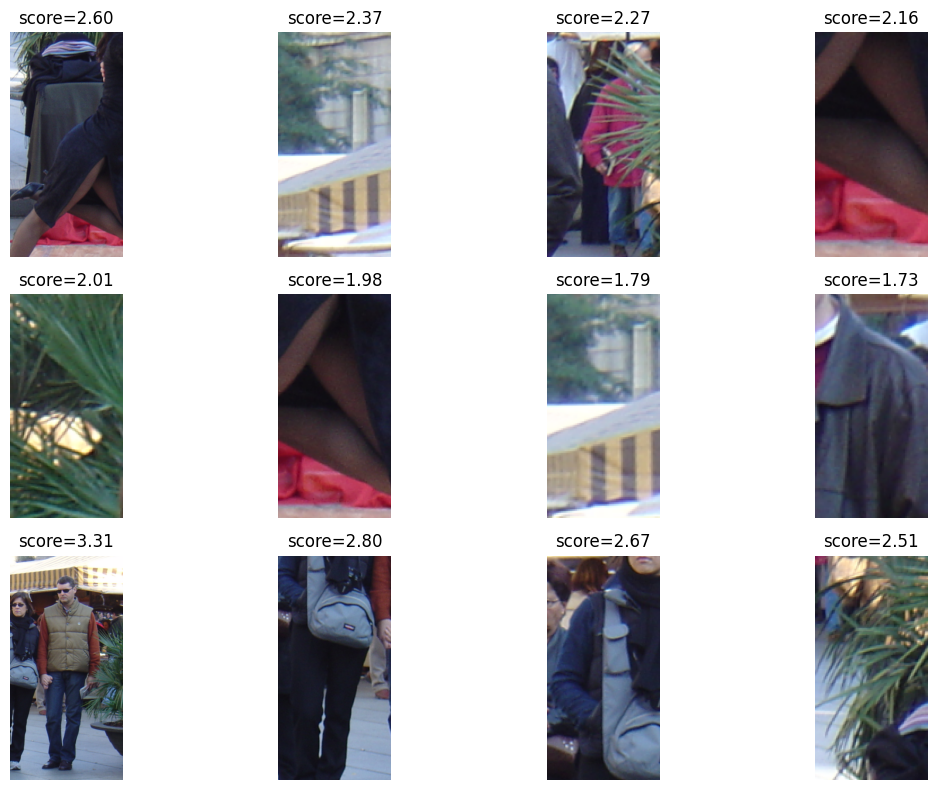

In [17]:
if len(hard_meta) == 0:
    print("Belum ada hard negative yang ditemukan. Coba turunkan HNM_THRESHOLD atau tambah HNM_LIMIT_IMAGES.")
else:
    plt.figure(figsize=(12, 8))
    show_n = min(12, len(hard_meta))

    for i in range(show_n):
        item = hard_meta[i]
        image = load_rgb_image(item["image"])
        x1, y1, x2, y2 = item["box"]
        crop = image[y1:y2, x1:x2]

        plt.subplot(3, 4, i + 1)
        plt.imshow(crop)
        plt.title(f"score={item['score']:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 13. Retrain Model Final dengan Hard Negative

Dataset final:
```text
X_train_final = X_train + X_hard
y_train_final = y_train + y_hard
```

Model final inilah yang nanti disimpan dan dipakai di Streamlit.

In [18]:
if len(X_hard) > 0:
    X_train_final = np.vstack([X_train, X_hard])
    y_train_final = np.concatenate([y_train, y_hard])
else:
    print("Peringatan: Tidak ada hard negative. Model final = model awal.")
    X_train_final = X_train.copy()
    y_train_final = y_train.copy()

print("X_train awal :", X_train.shape)
print("X_hard       :", X_hard.shape if len(X_hard) > 0 else "(kosong)")
print("X_train final:", X_train_final.shape)
print("Distribusi final [Non-Human, Human]:", np.bincount(y_train_final))

# C=0.01 untuk final model setelah HNM: regularisasi lebih kuat agar
# model tidak overfit terhadap hard negative yang mungkin ada noise
FINAL_C = 0.01

svm_model = create_svm_model(C=FINAL_C)
svm_model.fit(X_train_final, y_train_final)

print("\nRetraining model final selesai.")
print(f"  INITIAL_C = {INITIAL_C}  (model awal untuk HNM)")
print(f"  FINAL_C   = {FINAL_C}    (model final untuk deployment)")


X_train awal : (2465, 3780)
X_hard       : (4657, 3780)
X_train final: (7122, 3780)
Distribusi final [Non-Human, Human]: [6130  992]

Retraining model final selesai.
  INITIAL_C = 0.1  (model awal untuk HNM)
  FINAL_C   = 0.01    (model final untuk deployment)


## 14. Evaluasi Validation Set Setelah Hard Negative Mining

Final Validation Accuracy: 0.86709886547812
              precision    recall  f1-score   support

   Non-Human       0.82      0.99      0.90       369
       Human       0.98      0.69      0.81       248

    accuracy                           0.87       617
   macro avg       0.90      0.84      0.85       617
weighted avg       0.89      0.87      0.86       617



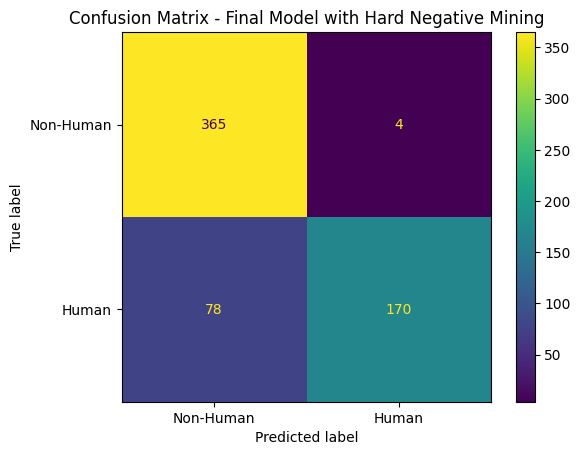

In [19]:
final_pred = svm_model.predict(X_val)

print("Final Validation Accuracy:", accuracy_score(y_val, final_pred))
print(classification_report(y_val, final_pred, target_names=["Non-Human", "Human"]))

cm_final = confusion_matrix(y_val, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Non-Human", "Human"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Final Model with Hard Negative Mining")
plt.show()

## 15. Evaluasi Test Set

In [20]:
X_test, y_test, test_meta = build_samples(
    image_dir=TEST_IMG_DIR,
    ann_dir=TEST_ANN_DIR,
    negative_per_image=3,
    limit=None
)

print("X_test:", X_test.shape)
print("Distribusi label test [Non-Human, Human]:", np.bincount(y_test))

Building initial samples: 100%|██████████| 288/288 [00:11<00:00, 25.34it/s]

Positive samples      : 597
Random negative samples: 864
X_test: (1461, 3780)
Distribusi label test [Non-Human, Human]: [864 597]


Test Accuracy: 0.8774811772758385
              precision    recall  f1-score   support

   Non-Human       0.83      0.99      0.91       864
       Human       0.98      0.71      0.83       597

    accuracy                           0.88      1461
   macro avg       0.91      0.85      0.87      1461
weighted avg       0.89      0.88      0.87      1461



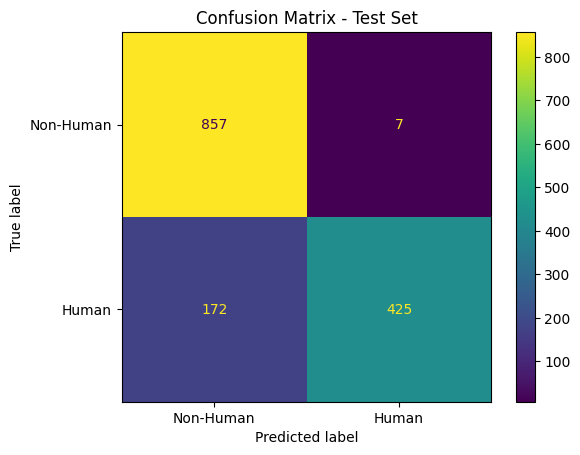

In [21]:
test_pred = svm_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred, target_names=["Non-Human", "Human"]))

cm_test = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Non-Human", "Human"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.show()

## 16. Simpan Model Package untuk Streamlit

File output:
```text
hog_svm_human_model_hnm.pkl
```

Package berisi:
- model SVM final
- konfigurasi HOG
- window size
- rekomendasi parameter deteksi

In [24]:
MODEL_PATH = "hog_svm_human_model_hnm.pkl"

model_package = {
    "model": svm_model,
    "window_size": WINDOW_SIZE,
    "hog_params": HOG_PARAMS,
    "training_info": {
        "method": "HOG + Linear SVM + Hard Negative Mining",
        "initial_C": INITIAL_C,
        "final_C": FINAL_C,
        "negative_per_image": 3,
        "hard_negative_count": int(len(X_hard)),
        "hnm_limit_images": HNM_LIMIT_IMAGES,
        "hnm_step_size": HNM_STEP_SIZE,
        "hnm_threshold": HNM_THRESHOLD,
        "hnm_downscale": HNM_DOWNSCALE,
        "hnm_iou_threshold": HNM_IOU_THRESHOLD
    },
    # Parameter ini dibaca Streamlit saat load model
    # Konsisten dengan parameter di cell demo (cell 17)
    "recommended_detection_params": {
        "step_size": 10,
        "threshold": 1.6,
        "downscale": 1.25,
        "nms_iou_threshold": 0.5,
        "max_width": 700
    }
}

joblib.dump(model_package, MODEL_PATH)
print(f"Model berhasil disimpan ke: {MODEL_PATH}")
print(f"Hard negative yang ditambahkan: {len(X_hard)}")
print(f"Recommended detection params: {model_package['recommended_detection_params']}")


Model berhasil disimpan ke: hog_svm_human_model_hnm.pkl
Hard negative yang ditambahkan: 4657
Recommended detection params: {'step_size': 10, 'threshold': 1.6, 'downscale': 1.25, 'nms_iou_threshold': 0.5, 'max_width': 700}


## 17. Demo Deteksi pada Gambar Test / Gambar Pribadi

Isi salah satu:
- `DEMO_IMAGE_PATH = None` untuk mengambil gambar pertama dari folder test
- `DEMO_IMAGE_PATH = "testing.png"` untuk gambar custom

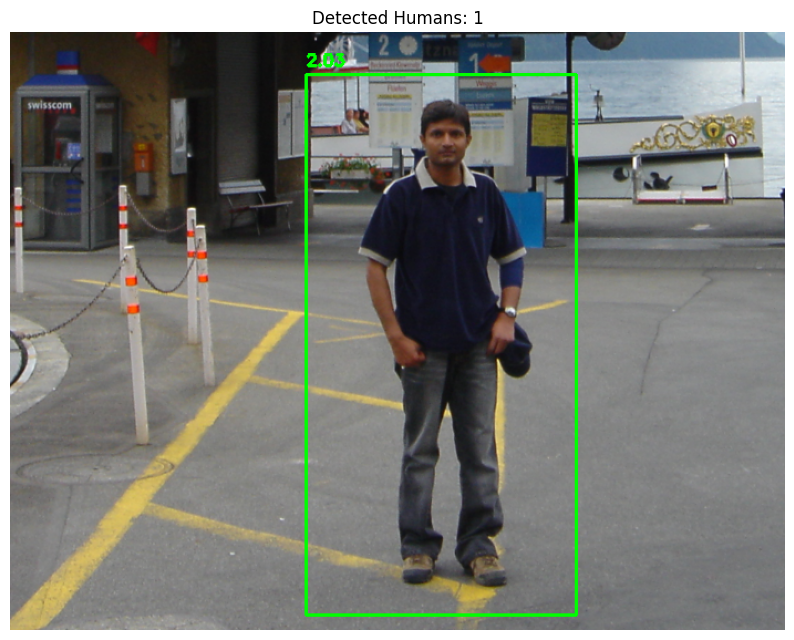

Image path            : testing.png
Detections before NMS : 1
Detections after NMS  : 1


In [25]:
DEMO_IMAGE_PATH = 'testing.png'  # ubah ke None untuk pakai gambar dari test set

if DEMO_IMAGE_PATH is None:
    if len(test_images) == 0:
        sample_img_path = None
    else:
        sample_img_path = test_images[2]
else:
    sample_img_path = Path(DEMO_IMAGE_PATH)

if sample_img_path is None:
    print("Tidak ada gambar demo. Periksa TEST_IMG_DIR atau isi DEMO_IMAGE_PATH.")
elif not Path(sample_img_path).exists():
    print(f"File tidak ditemukan: {sample_img_path}")
else:
    image_bgr = cv2.imread(str(sample_img_path))

    if image_bgr is None:
        print(f"Gagal membaca gambar: {sample_img_path}")
    else:
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        # Resize agar deteksi tidak terlalu lambat (max 700px lebar)
        max_width = 700
        h, w = image_rgb.shape[:2]
        if w > max_width:
            scale_ratio = max_width / w
            image_demo = cv2.resize(image_rgb, (int(w * scale_ratio), int(h * scale_ratio)))
        else:
            image_demo = image_rgb.copy()

        # ── Parameter deteksi ─────────────────────────────────────────────────
        # threshold  : naikkan jika false positive masih banyak (coba 1.2 – 1.5)
        # iou_thresh : jangan terlalu rendah — orang berdekatan bisa ikut dibuang
        # step_size  : 10 sudah presisi, turunkan ke 8 jika hasil kurang tepat
        DETECTION_THRESHOLD = 1.1
        NMS_IOU_THRESHOLD   = 0.35  # 0.2 terlalu agresif → orang berdekatan bisa hilang
        STEP_SIZE           = 10    # 6 terlalu lambat tanpa peningkatan signifikan
        DOWNSCALE           = 1.25
        # ─────────────────────────────────────────────────────────────────────

        detections = detect_humans_multiscale(
            image_demo,
            model=svm_model,
            step_size=STEP_SIZE,
            threshold=DETECTION_THRESHOLD,
            downscale=DOWNSCALE
        )

        final_boxes = non_max_suppression(detections, iou_threshold=NMS_IOU_THRESHOLD)

        boxes_only = [(x1, y1, x2, y2) for (x1, y1, x2, y2, score) in final_boxes]
        labels     = [f"{score:.2f}" for (_, _, _, _, score) in final_boxes]

        result = draw_boxes(image_demo, boxes_only, color=(0, 255, 0), thickness=2, labels=labels)

        plt.figure(figsize=(10, 8))
        plt.imshow(result)
        plt.title(f"Detected Humans: {len(final_boxes)}")
        plt.axis("off")
        plt.show()

        print("Image path            :", sample_img_path)
        print("Detections before NMS :", len(detections))
        print("Detections after NMS  :", len(final_boxes))


## 18. Catatan Implementasi Streamlit

Di Streamlit nanti:
1. Load file `hog_svm_human_model_hnm.pkl`
2. Ambil `model`, `window_size`, dan `hog_params`
3. Upload gambar
4. Jalankan fungsi:
   - `extract_hog_features`
   - `sliding_window`
   - `detect_humans_multiscale`
   - `non_max_suppression`
5. Tampilkan bounding box dan jumlah manusia

Catatan penting:
- Hard Negative Mining **mengurangi false positive**, tetapi tidak menjamin 0 kesalahan pada semua gambar.
- Jika masih ada false positive, tuning paling berpengaruh:
  - naikkan `DETECTION_THRESHOLD`, misalnya 1.2–1.8
  - naikkan jumlah `HNM_LIMIT_IMAGES`
  - naikkan `negative_per_image`
  - gunakan `STEP_SIZE` lebih kecil untuk akurasi, tetapi lebih lambat